# 반도체 수율 — Ontology 기반 SHAP 평가 가이드 (2가지 모드)

이 노트북은 **실제 데이터**로 평가를 실행합니다. 아래 두 흐름은 *CatBoost를 직접 학습하느냐* 만 다르고, 그 뒤의 ontology 반영·SHAP 해석은 동일합니다.

| MODE | 흐름 |
|---|---|
| **1** | 실제 데이터 로드 → 온톨로지 반영 → **CatBoost 학습** → SHAP 분석 · ontology 반영 SHAP 분석 → 결과 해석 |
| **2** | 실제 데이터 로드 → 온톨로지 반영 → (제공된) SHAP 분석 · ontology 반영 SHAP 분석 → 결과 해석 |

- **MODE 1**: 우리가 flat / ontology CatBoost 를 직접 학습하고, 학습된 ontology 모델의 SHAP 으로 해석합니다. (제공된 SHAP 파일이 없어도 됩니다 — 모델이 직접 SHAP 을 만듭니다.)
- **MODE 2**: 회사 production 모델이 만든 **제공된 SHAP**(`bad_wafer_shap_value.csv` / `all_wafer_shap_value.csv`)을 그대로 ontology 로 해석합니다. (학습 단계 없음.)

## 사용법
1. 아래 **설정 셀**에서 `MODE` 를 1 또는 2 로 정합니다.
2. 실제 데이터로 평가하려면 `USE_VIRTUAL_DEMO_DATA = False` 로 두고 `input/` 에 계약 파일을 넣습니다.
3. 메뉴에서 **Restart & Run All**.

```text
input/raw_data.csv              # 공통 필수: root_lot_id, wafer_id, tkout_time, target, feature columns
input/prc_metro_relation.csv    # 공통 필수: prc_step, metro_step, metro_item, subitem_id, metro_grade
input/bad_wafer_shap_value.csv  # MODE 2 필수: bad wafer SHAP (wide: wafer 1행 x feature 컬럼)
input/all_wafer_shap_value.csv  # MODE 2 권장: good+bad SHAP (wide) — good vs bad 비교
input/bad_wafers.csv            # 선택: bad wafer cohort
```

> 📓 미리 실행된 사본 2개가 함께 제공됩니다: **`evaluation_guide.ipynb`**(MODE 1 결과), **`evaluation_guide_mode2.ipynb`**(MODE 2 결과). 둘은 동일한 노트북이며, 아무 파일에서나 아래 `MODE` 값을 바꿔 `Restart & Run All` 하면 해당 모드로 다시 실행됩니다.

## ⚙️ 설정
- **`BAD_QUANTILE`**: bad wafer 판정 기준. 기본값 `None` 은 **`input/bad_wafers.csv`(또는 `bad_wafer_list.csv`) 의 bad wafer 리스트를 사용**합니다(권장). 리스트가 없고 target 상위 분위로 잡고 싶을 때만 `0.0~1.0` 값(예: `0.80`)을 넣으세요. 리스트가 있으면 `BAD_QUANTILE` 값은 무시됩니다.

In [1]:
MODE = 2                       # 1: CatBoost 학습 후 해석 / 2: 제공된 SHAP 으로 해석
USE_VIRTUAL_DEMO_DATA = True   # 실데이터 평가 시 False 로 두고 input/ 에 실제 파일을 넣으세요
ITERATIONS = 200               # MODE 1 CatBoost iterations
SEED = 42
BAD_QUANTILE = None            # None=bad_wafers.csv 리스트 사용(권장). 분위 기준은 0~1 값(예: 0.80)
assert MODE in (1, 2)

## 0. 환경 준비 (import / 경로)

In [2]:
import os, sys
ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, 'requirements.txt')) and ROOT != os.path.dirname(ROOT):
    ROOT = os.path.dirname(ROOT)
os.chdir(ROOT)                 # 상대경로(data/, catboost_info/)를 repo 루트로 고정
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np, pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 60); pd.set_option('display.width', 180)

from src.real_dataset_adapter import build_standard_dataset, build_feature_level_shap
from src.virtual_data_generator import generate_virtual_input_dataset
from src.loaders import load_all_data
from src.pipeline import run_analysis
from scripts import model_comparison_demo as mc

# INPUT_DIR : 원천 입력 (사용자가 넣는 데이터) — raw_data, prc_metro_relation, SHAP, bad_wafers
# DATA_DIR  : build_standard_dataset 가 생성하는 표준 중간 산출물 (분석 입력) —
#             feature_matrix / target(+bad_flag) / shap_values / feature_dictionary /
#             causal_edges / mediation / shap_cohort_comparison
# OUT_DIR   : 최종 산출물 — report.md / hypothesis_cards.csv / ontology_level_shap_summary.csv
INPUT_DIR, DATA_DIR, OUT_DIR = 'input', 'data', 'outputs'
print('ROOT =', ROOT, '| MODE =', MODE)

ROOT = /home/user/ontology_demo_claude_codex | MODE = 2


## (선택) 데모 데이터
실데이터가 없을 때만 동작하는 **격리된 셀**입니다. `USE_VIRTUAL_DEMO_DATA=True` 이고 `input/` 에 원천 데이터가 없으면 가상 데이터를 생성합니다. 실데이터가 이미 있으면 건드리지 않습니다. 평가 흐름(아래)은 데이터 출처와 무관하게 동일합니다.

In [3]:
core = ['raw_data.csv', 'prc_metro_relation.csv']
have_core = all(os.path.exists(os.path.join(INPUT_DIR, f)) for f in core)
if not have_core:
    if USE_VIRTUAL_DEMO_DATA:
        generate_virtual_input_dataset(INPUT_DIR, n_wafers=250, seed=SEED)
        print('[DEMO] 가상 데이터를 input/ 에 생성했습니다. (평가는 실데이터 권장)')
    else:
        raise FileNotFoundError(f'input/ 에 {core} 가 필요합니다. 실데이터를 넣거나 USE_VIRTUAL_DEMO_DATA=True 로 두세요.')
print('input files:', sorted(os.listdir(INPUT_DIR)))

[DEMO] 가상 데이터를 input/ 에 생성했습니다. (평가는 실데이터 권장)
input files: ['all_wafer_shap_value.csv', 'bad_wafer_shap_value.csv', 'bad_wafers.csv', 'prc_metro_relation.csv', 'raw_data.csv', 'x_feature_shap_value.csv']


## 0.5 입력 점검 (preflight) — **데이터를 갈아끼웠다면 먼저 실행**
필수 파일·컬럼, target 숫자 여부, **wide SHAP 컬럼명이 raw_data feature명과 일치하는지**, bad wafer 리스트가 raw_data 안에 있는지 등을 한 번에 점검합니다. ❌ 가 있으면 실행을 중단합니다.

In [4]:
from src.input_check import check_inputs, format_report
report = check_inputs(INPUT_DIR, require_shap=(MODE == 2))
print(format_report(report))
if not report['ok']:
    raise ValueError('입력 점검 실패: 위 ❌ 항목을 수정한 뒤 다시 실행하세요.')

입력 점검 (preflight)
  ✅ raw_data.csv: wafer 250행, feature 9개
  ✅ prc_metro_relation.csv: 공정-계측 관계 1건
  ✅ SHAP 입력: bad_wafer_shap_value.csv, all_wafer_shap_value.csv, x_feature_shap_value.csv
  ✅ bad_wafer_shap_value.csv: feature 9/9 일치
  ✅ all_wafer_shap_value.csv: feature 9/9 일치
  ✅ bad wafer 판정: 리스트 사용 (50개)
----------------------------------------
  결과: ✅ 통과 — 실행 가능


## 1. 실제 데이터 로드 + 온톨로지 반영 (공통)
두 모드 공통 단계입니다. `input/`(INPUT_DIR)의 원천 데이터를 읽어 `data/`(DATA_DIR)에 표준 산출물을 만듭니다. `raw_data` + `prc_metro_relation` 으로 feature 의 **causal role**, **causal edge graph**, 그리고 raw 값으로 **측정한 매개효과(root→metro→target)** 를 생성합니다.
MODE 1 은 SHAP 입력 없이 빌드(`require_shap=False`)하고, MODE 2 는 제공된 SHAP 을 함께 빌드합니다.
bad wafer 는 `bad_wafers.csv` 리스트가 있으면 그걸 쓰고(권장), 없으면 `BAD_QUANTILE` 값으로 판정합니다.

In [5]:
art = build_standard_dataset(INPUT_DIR, DATA_DIR, bad_quantile=BAD_QUANTILE, require_shap=(MODE == 2))
raw = pd.read_csv(os.path.join(INPUT_DIR, 'raw_data.csv'))
target = art.target
has_list = any(os.path.exists(os.path.join(INPUT_DIR, f)) for f in ['bad_wafers.csv', 'bad_wafer_list.csv'])
print('bad wafer 판정:', 'bad_wafers.csv 리스트' if has_list else f'target quantile={BAD_QUANTILE}')
print('wafers:', len(target), '| bad wafers:', int(target['bad_flag'].sum()))

print('\n온톨로지 — feature 역할(causal role):')
display(art.feature_dictionary[['feature_id','source_type','process_step','causal_role','mechanism_group']])

print('온톨로지 — 측정된 매개효과 (root -> mediator -> target):')
med = art.mediation
if med is not None and not med.empty:
    cols = ['root','mediator','a','b','indirect','prop_mediated','indirect_p','indirect_q','n']
    display(med.sort_values('indirect', key=lambda s: s.abs(), ascending=False)[cols])
else:
    print('  측정된 사슬 없음 (N 부족 / 이름규칙 / 공선성)')

bad wafer 판정: bad_wafers.csv 리스트
wafers: 250 | bad wafers: 50

온톨로지 — feature 역할(causal role):


,feature_id,source_type,process_step,causal_role,mechanism_group
0,cat|ppid|CVD,PROCESS_HISTORY,CVD,confounder,ppid_grouping
1,cat|eqp|CVD,PROCESS_HISTORY,CVD,confounder,eqp_grouping
2,cat|eqp_ch|CVD,PROCESS_HISTORY,CVD,confounder,eqp_ch_grouping
3,cat|slot_n|CVD,PROCESS_HISTORY,CVD,confounder,slot_n_grouping
4,num|CVD|erd|pcf|PRESSURE_SLOPE_P95|CVD,ERD,CVD,root_cause_candidate,PRESSURE_SLOPE_P95
5,num|MET_CVD|THK_EDGE|AVG,METROLOGY,CVD,mediator_candidate,metro_THK_EDGE
6,num|CVD|RF_TIME_1|VALUE,VM,CVD,root_cause_candidate,RF_TIME_1
7,num|ETCH|QUEUE_TIME|VALUE,VM,ETCH,root_cause_candidate,QUEUE_TIME
8,num|FINAL|TARGET_PROXY|VALUE,UNKNOWN,-,leakage_or_post_outcome,post_outcome_proxy


온톨로지 — 측정된 매개효과 (root -> mediator -> target):


,root,mediator,a,b,indirect,prop_mediated,indirect_p,indirect_q,n
0,num|CVD|erd|pcf|PRESSURE_SLOPE_P95|CVD,num|MET_CVD|THK_EDGE|AVG,0.938474,0.857128,0.804393,0.915909,0.0,0.0,250
1,num|CVD|RF_TIME_1|VALUE,num|MET_CVD|THK_EDGE|AVG,0.554823,0.904026,0.501574,0.925469,0.0,0.0,250


## 2. SHAP 확보 — 모드별 분기
- **MODE 1**: flat vs ontology CatBoost 를 **학습**하고(성능 비교), 학습된 ontology 모델의 **bad wafer cohort SHAP** 을 표준 `shap_values.csv` 로 기록합니다.
- **MODE 2**: 제공된 SHAP 이 이미 `shap_values.csv` 로 빌드되어 있습니다 (학습 없음).

In [6]:
mc_res = None
if MODE == 1:
    ds = mc.dataset_from_artifacts(art, source='real')
    bad_mask = (target['bad_flag'] == 1).to_numpy()
    # (a) 학습 + 성능 비교 (flat vs ontology) — 5블록 결과는 아래 4절에서 출력
    mc_res = mc.compute_results(ds, iterations=ITERATIONS, seed=SEED)
    # (b) 학습된 ontology 모델의 bad-cohort SHAP -> 표준 shap_values 로 기록
    cohort = mc.trained_ontology_cohort_shap(ds, bad_mask, iterations=ITERATIONS, seed=SEED)
    build_feature_level_shap(cohort, raw, target).to_csv(os.path.join(DATA_DIR, 'shap_values.csv'), index=False)
    SHAP_SOURCE = '학습한 ontology CatBoost 의 SHAP'
    print('top features by mean|SHAP| (학습 모델):')
    display(cohort.head(8))
else:
    SHAP_SOURCE = '제공된 production SHAP (input/*shap*.csv)'
    print('SHAP 출처:', SHAP_SOURCE)
    print('bad wafer cohort SHAP (제공값, top):')
    display(load_all_data(DATA_DIR)['shap_values']
            .sort_values('abs_shap_value', ascending=False)
            [['feature_id','shap_value','abs_shap_value','shap_direction']].head(8))

SHAP 출처: 제공된 production SHAP (input/*shap*.csv)
bad wafer cohort SHAP (제공값, top):


,feature_id,shap_value,abs_shap_value,shap_direction
0,num|FINAL|TARGET_PROXY|VALUE,3.274210,3.274210,+
1,num|MET_CVD|THK_EDGE|AVG,1.824068,1.824068,+
2,num|CVD|erd|pcf|PRESSURE_SLOPE_P95|CVD,1.090603,1.097463,+
3,num|CVD|RF_TIME_1|VALUE,0.276985,0.352109,+
4,cat|ppid|CVD,0.181495,0.240029,+
5,cat|eqp_ch|CVD,0.154171,0.200017,+
6,num|ETCH|QUEUE_TIME|VALUE,0.056527,0.185081,+
7,cat|slot_n|CVD,-0.009867,0.060467,-


## 3. SHAP 분석 + ontology 반영 SHAP 분석 + 결과 해석 (공통)
`run_analysis` 가 ① raw SHAP 순위 → ② ontology 그래프 상류 추적(증상 mediator → controllable root) → ③ 인과 가설 카드 + grade + `outputs/report.md` 를 생성합니다. SHAP 출처(학습/제공)만 다를 뿐 분석 코드는 동일합니다.

In [7]:
res = run_analysis(DATA_DIR, OUT_DIR)
cards = res['cards']
card_cols = ['hypothesis_id','hypothesis_grade','primary_process_step',
             'root_cause_candidate_features','mediator_candidate_features',
             'evidence_basis','evidence_path_text']
print('SHAP 출처:', SHAP_SOURCE)
display(cards[[c for c in card_cols if c in cards.columns]])

s = res['summary']
print('naive top-SHAP (증상/symptom):', s['naive_top_nonleak'], '->', s['naive_top_nonleak_role'])
print('ontology 추적 root (원인/cause):', s['ontology_root'])

print('\nontology 반영 SHAP 집계 (causal role 별):')
osum = res['ontology_summary']
display(osum[osum['group_kind'] == 'causal_role'][['causal_role','mean_abs_shap','total_abs_shap','n_rows']])

SHAP 출처: 제공된 production SHAP (input/*shap*.csv)


,hypothesis_id,hypothesis_grade,primary_process_step,root_cause_candidate_features,mediator_candidate_features,evidence_basis,evidence_path_text
0,HYP_001,A,CVD,num|CVD|erd|pcf|PRESSURE_SLOPE_P95|CVD,num|MET_CVD|THK_EDGE|AVG,measured,num|CVD|erd|pcf|PRESSURE_SLOPE_P95|CVD ↑ → num...
1,HYP_002,C,ETCH,num|ETCH|QUEUE_TIME|VALUE,,naming_only,QUEUE_TIME → 불량률 상승 (집중 챔버: CVD_CH_03)
2,HYP_003,X,FINAL_TEST,,,NaN,누설(leakage) feature — 인과 경로 추적 대상 아님


naive top-SHAP (증상/symptom): num|MET_CVD|THK_EDGE|AVG -> mediator_candidate
ontology 추적 root (원인/cause): num|CVD|erd|pcf|PRESSURE_SLOPE_P95|CVD

ontology 반영 SHAP 집계 (causal role 별):


,causal_role,mean_abs_shap,total_abs_shap,n_rows
0,leakage_or_post_outcome,3.274210,3.274210,1
1,mediator_candidate,1.824068,1.824068,1
2,root_cause_candidate,0.544884,1.634653,3
3,confounder,0.129211,0.516844,4


## 4. 모드별 추가 결과
- **MODE 1**: 성능 비교 5블록(R²·attribution·role roll-up·measured chain·learning curve) + 차트.
- **MODE 2**: good vs bad SHAP cohort 비교 + 제공 모델의 credit-absorption 진단.

good vs bad SHAP cohort 비교 (제공 모델이 bad 에서 더 의존하는 feature):


,feature_id,causal_role,bad_mean_abs_shap,good_mean_abs_shap,abs_shap_gap_bad_minus_good
0,num|FINAL|TARGET_PROXY|VALUE,leakage_or_post_outcome,3.274210,1.458324,1.815886
1,num|MET_CVD|THK_EDGE|AVG,mediator_candidate,1.824068,0.923462,0.900606
2,num|CVD|erd|pcf|PRESSURE_SLOPE_P95|CVD,root_cause_candidate,1.097463,0.556310,0.541153
3,num|CVD|RF_TIME_1|VALUE,root_cause_candidate,0.352109,0.233186,0.118923
4,cat|ppid|CVD,confounder,0.240029,0.144689,0.095340
5,cat|eqp_ch|CVD,confounder,0.200017,0.119972,0.080045
6,num|ETCH|QUEUE_TIME|VALUE,root_cause_candidate,0.185081,0.175086,0.009995
7,cat|slot_n|CVD,confounder,0.060467,0.051287,0.009180
8,cat|eqp|CVD,confounder,0.016331,0.016334,-0.000003


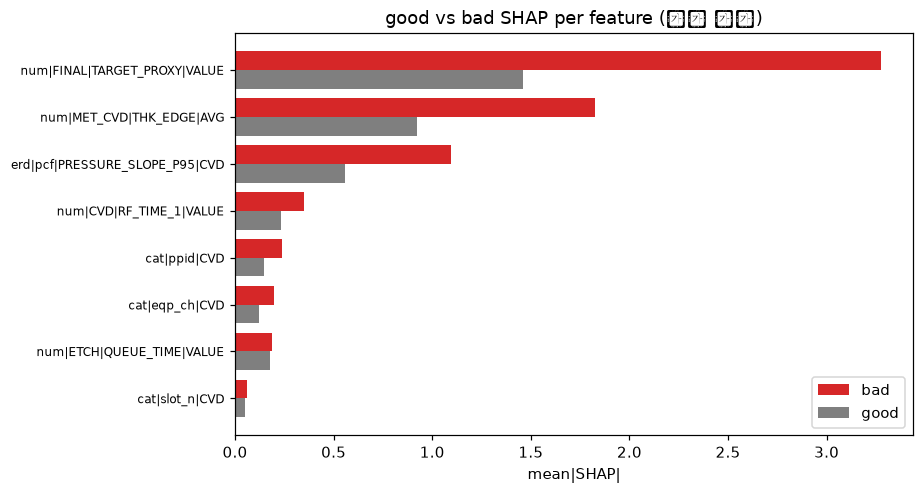


6) PROVIDED MODEL SHAP  (your production CatBoost, from all_wafer_shap_value.csv; rolled up by role)
  top features by mean|SHAP| (provided model):
     41.5%  [leakage_or_post_outcome] num|FINAL|TARGET_PROXY|VALUE
     25.1%  [mediator_candidate    ] num|MET_CVD|THK_EDGE|AVG
     15.1%  [root_cause_candidate  ] num|CVD|erd|pcf|PRESSURE_SLOPE_P95|CVD
      5.8%  [root_cause_candidate  ] num|CVD|RF_TIME_1|VALUE
      4.0%  [root_cause_candidate  ] num|ETCH|QUEUE_TIME|VALUE
      3.7%  [confounder            ] cat|ppid|CVD
  roll-up by causal role:
     41.5%  leakage_or_post_outcome
     25.1%  mediator_candidate
     25.0%  root_cause_candidate
      8.4%  confounder
  CREDIT ABSORPTION in your production model (measured root vs your SHAP share):
    root num|CVD|erd|pcf|PRESSURE_SLOPE_P95|CVD: measured indirect=0.80 but provided SHAP 15.1% < mediator 25.1%
    root num|CVD|RF_TIME_1|VALUE: measured indirect=0.50 but provided SHAP 5.8% < mediator 25.1%


,role,mean_abs_shap,pct
0,leakage_or_post_outcome,1.821501,41.464901
1,mediator_candidate,1.103584,25.122124
2,root_cause_candidate,1.098595,25.008572
3,confounder,0.369195,8.404403


In [8]:
if MODE == 1 and mc_res is not None:
    mc.print_report(mc_res)                       # PERFORMANCE / ATTRIBUTION / ROLL-UP / CHAIN / LEARNING CURVE
    from src.model_comparison_viz import all_figures
    for name, fig in all_figures(mc_res).items():
        display(fig); plt.close(fig)

elif MODE == 2:
    comp = art.shap_cohort_comparison
    if comp is not None and not comp.empty:
        print('good vs bad SHAP cohort 비교 (제공 모델이 bad 에서 더 의존하는 feature):')
        cc = ['feature_id','causal_role','bad_mean_abs_shap','good_mean_abs_shap','abs_shap_gap_bad_minus_good']
        display(comp[cc].head(10))
        top = comp.head(8).iloc[::-1]; y = np.arange(len(top)); h = 0.4
        fig, ax = plt.subplots(figsize=(8.5, 4.6))
        ax.barh(y + h/2, top['bad_mean_abs_shap'], h, label='bad', color='#d62728')
        ax.barh(y - h/2, top['good_mean_abs_shap'], h, label='good', color='#7f7f7f')
        ax.set_yticks(y); ax.set_yticklabels([str(f)[-30:] for f in top['feature_id']], fontsize=8)
        ax.set_xlabel('mean|SHAP|'); ax.legend(); ax.set_title('good vs bad SHAP per feature (제공 모델)')
        plt.tight_layout(); plt.show()
    else:
        print('all_wafer_shap_value.csv 가 없어 cohort 비교를 건너뜁니다.')
    ds = mc.dataset_from_artifacts(art, source='real')
    ps = mc.analyze_provided_shap(INPUT_DIR, ds)
    if ps is not None:
        mc.print_provided_shap(ps)
        display(ps.rollup)
    else:
        print('wide SHAP 파일이 없어 provided-model 해석을 건너뜁니다.')

## 정리
- 공통: 실데이터 → 온톨로지(역할·그래프·측정 매개효과) → SHAP 분석 → ontology 반영 SHAP 해석 → 인과 가설 카드.
- **MODE 1** vs **MODE 2** 의 유일한 차이는 **CatBoost 학습 단계**(= SHAP 출처)입니다.
  - MODE 1: 학습된 ontology 모델 SHAP + 성능 비교(flat vs ontology).
  - MODE 2: 제공된 production SHAP + good/bad 비교 + credit-absorption 진단.
- 산출물: `data/*.csv`, `outputs/report.md`, `outputs/hypothesis_cards.csv`(MODE 2 면 `data/shap_cohort_comparison.csv`).
- 실데이터 적용: 위 설정에서 `USE_VIRTUAL_DEMO_DATA=False`, `input/` 에 계약 파일 → `Restart & Run All`.
- 테스트: repo 루트에서 `python3 -m pytest tests/ -q`.